In [ ]:
### DESERTIFICATION AND CARBON PROXY MAPPING WITH HYPERSPECTRAL IMAGES EO-1 HYPERION (L1T), SENTINEL1, LANDSAT8 AND DEM

# Import libraries
import os
import glob
import json
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import median_filter
from scipy.optimize import nnls
import spectral as sp
from spectral import calc_stats, noise_from_diffs, mnf
from spectral.algorithms import GaussianStats
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GroupKFold
from pyproj import Transformer
import gc
import ee
import warnings
warnings.filterwarnings('ignore')

try:
    from pysptools.eea import vca
    from pysptools.spectra import fcls
    pysptools_available = True
except Exception:
    pysptools_available = False

print('Libraries loaded. Pysptools availability:', pysptools_available)

Libraries loaded. Pysptools availability: False


In [ ]:
# Set parameters and configuration

# Input and output file paths
DATA_DIR = r"C:\Users\Francesco\Python\earthlab\China\data\EO1H1240302014207110KF_1T"
OUTPUT_DIR = r"C:\Users\Francesco\Python\earthlab\China\data\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperion specifics
ASSUME_RADIANCE = True  # False if data are already in reflectance values
SAVGOL_WINDOW = 9
SAVGOL_POLY = 2
PCA_COMPONENTS = 10

# UTM coordinates to query local literature parameters values and for visualization
UTM_X = 447105 # Random point around the center of the image
UTM_Y = 4748322 
UTM_ZONE = 50
UTM_NORTH = True

HYP_PCA_ASSET = r"C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_pca10.tif"  # For PCA results
HYP_IND_ASSET = r"C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_indices.tif"  # For spectral indices (NDVI, NDWI, etc.)
HYP_FRAC_ASSET = r"C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_fractions.tif"  # For fractional cover/abundance maps

# Use NASA/ORNL as a Global AGB surrogate for training as soft labels
GLOBAL_AGB_ID = 'NASA/ORNL/biomass_carbon_density/v1'
NASA_UNCERTAINTY_THRESHOLD = 30 # Mg/ha uncertainty threshold (to filter out high-uncertainty pixels)

# Dryland class AGB values (Mg/ha) - from literature on Inner Mongolia
DRYLAND_AGB_CLASS_VALUES = {'bare_soil': 0.15,      # Xu et al. 2018: 0.1-0.3 Mg/ha for desert soil
                            'sparse_shrub': 1.2,    # Liu et al. 2014: 0.8-1.5 Mg/ha for Caragana microphylla
                            'grassland': 3.5,       # Wang et al. 2020: 2.5-4.5 Mg/ha for Leymus chinensis steppe
                            'dense_shrub': 8.0,     # Gao et al. 2019: 6-10 Mg/ha for dense Caragana stands
                            'wet_meadow': 6.0,      # If present - based on Inner Mongolia wetland studies
                            'cropland': 2.0         # Approximate value forland used for agriculture
                            }

# ICESat-2 allometric parameters for dryland shrubs/grasslands in Inner Mongolia
# Biomass = a*height^b (allometric equation)
ICESAT2_ALLOMETRIC_A = 0.42 # Scaling parameter
ICESAT2_ALLOMETRIC_B = 1.35 # Height exponent

# Sample confidence weights (for weighted training)
SAMPLE_WEIGHTS = {'icesat2': 1.0,           # Highest confidence (direct mesaurements)
                  'nasa_high_conf': 0.7,    # NASA/ORNL with low uncertainty
                  'nasa_low_conf': 0.3,     # NASA/ORNL with high uncertainty
                  'literature': 0.5,        # Literature-based class values
                  'default': 0.2            # Fallback
                  }

# Vegetation type-specific AGB caps (Mg/ha) to prevent unrealistic values
VEGETATION_AGB_CAPS = {'grassland':{'min': 0.1, 'max': 15},
                       'shrubland':{'min': 0.5, 'max': 25},
                       'cropland': {'min': 0.1, 'max': 10},
                       'wetland': {'min': 0.5, 'max': 30},
                       'default': {'min': 0.0, 'max': 50}}

In [9]:
# Load and stack the hyperspectral images

# Function to read the EO-1 Hyperion bands and stack them into (rows, cols, bands)
def stack_hyperion_bands(folder):
    
    # Get the list of band/file names
    files = sorted(glob.glob(os.path.join(folder, '*_B*_L1T.TIF')))

    arrays = []
    meta = None
    for f in files:
        with rasterio.open(f) as src:
            band = src.read(1).astype(np.float32)
            arrays.append(band)
            if meta is None:
                meta = src.meta.copy()
    
    cube = np.stack(arrays, axis=2) # (rows, cols, bands)
    
    band_files = files
    
    return cube, meta, band_files

# Read the EO_1 Hyp bands and stack them
cube, meta, band_files = stack_hyperion_bands(DATA_DIR)
rows, cols, bands = cube.shape
print('Cube shape (rows, cols, bands):', cube.shape)
print('Sample band file:', band_files[0])

# Get the transform and the crs
transform = meta['transform']
crs = meta['crs']

# Build an approximate wavelenght vector of EO_1 Hyp (because information absent in the metadata)
wvl = np.linspace(400, 2500, bands)

Cube shape (rows, cols, bands): (3241, 1271, 242)
Sample band file: C:\Users\Francesco\Python\earthlab\China\data\EO1H1240302014207110KF_1T\EO1H1240302014207110KF_B001_L1T.TIF


In [10]:
# Clip AOI from hyperspectral image footprint

# Get the bounding box from the image
left, top = transform * (0,0)
right, bottom = transform * (rows, cols)
minx, maxx = min(left, right), max(left, right)
miny, maxy = min(top, bottom), max(top, bottom)
print('Image bbox (crs):', minx, miny, maxx, maxy)

# Convert UTM point in the image to latlon (WGS84)
utm_zone = UTM_ZONE
hemisphere = 'north' if UTM_NORTH else 'south'
utm_crs = f'+proj=utm +zone={utm_zone} +{hemisphere} +ellps=WGS84 +datum=WGS84 +units=m +no_defs'
transformer = Transformer.from_crs(utm_crs, 'epsg:4326', always_xy=True)
lon, lat = transformer.transform(UTM_X, UTM_Y)

Image bbox (crs): 427500.0 4756181.764837265 524653.501253128 4794300.0


In [11]:
# Remove from the hyp images the noisy bands (water absorption and noisy edges)
water_mask = ((wvl >= 1340) & (wvl <= 1445)) | ((wvl >= 1790) & (wvl <= 1970))
edge_mask = (wvl < 430) | (wvl > 2450)
remove_mask = water_mask | edge_mask
keep_idx = [i for i in range(len(wvl)) if not remove_mask[i]]
print(f'Kept {len(keep_idx)} of {len(wvl)}')
wvl = wvl[keep_idx]
cube = cube[:, :, keep_idx]
rows, cols, bands = cube.shape
print(f'New cube shape: {cube.shape}')

Kept 199 of 242
New cube shape: (3241, 1271, 199)


In [12]:
# Convert radiance to reflectance
if ASSUME_RADIANCE:
    sun_elev = None
    try:
        with rasterio.open(band_files[0]) as src:
            # get a dictionary of the metadata with keys and their values
            tags = src.tags()

            for key in ['SUN_ELEVATION', 'SunElevation', 'SUN_ELEV']:
                if key in tags:
                    sun_elev = float(tags[key])
                    break
    except Exception:
        sun_elev = None
    
    if sun_elev is None:
        sun_elev = 45.0

    sun_zenith = np.deg2rad(90.0 - sun_elev)
    # radiance
    L = cube.astype(np.float32)
    
    # reflectance
    refl = (np.pi * L)/np.cos(sun_zenith)
      
    # Get 1st and 99th percentiles of the reflectance
    p1, p99 = np.percentile(refl, [1, 99])

    # Scale/clip the reflectance for stability
    refl = (refl - p1)/(p99 - p1 + 1e-9) * 0.9
else:
    refl = cube.astype(np.float32)

In [13]:
# For now the MNF method to filter reflectance noise is not used because of the running out of the RAM during the processing.

# Denoise the reflectance with the Minimum Noise Fraction method
# The MNF model is created on a sample pixels to avoid heavy calculation on the full image that the laptop cannot sustain
# Then the MNF transform is applied to the full cube

#def sample_noise_from_diffs(refl, n_samples=30000):
#    rows, cols, bands = refl.shape
    
    # vertical differences (one noise sample per pixel pair)
#    diffs = refl[1:, :, :] - refl[:-1, :, :]   # shape (rows-1, cols, bands)
#    diffs2D = diffs.reshape(-1, bands)

    # filter NaNs
#    diffs2D = diffs2D[np.all(np.isfinite(diffs2D), axis=1)]

    # sample without replacement
#    n = min(n_samples, diffs2D.shape[0])
#    idx = np.random.choice(diffs2D.shape[0], n, replace=False)
    
#    return diffs2D[idx]

#noise_sample = sample_noise_from_diffs(refl, n_samples=30000)
#noise_stats = GaussianStats(noise_sample)

# reshape data
#data2D = refl.reshape(-1, bands)
#data2D_valid = data2D[np.all(np.isfinite(data2D), axis=1)]

# sample signal
#N_SIGNAL = min(30000, data2D_valid.shape[0])
#idx = np.random.choice(data2D_valid.shape[0], N_SIGNAL, replace=False)
#signal_sample = data2D_valid[idx]

#signal_stats = GaussianStats(signal_sample)

# sample noise (MEMORY-SAFE)
#noise_sample = sample_noise_from_diffs(refl, n_samples=30000)
#noise_stats = GaussianStats(noise_sample)

# compute MNF
#mnf_model = mnf(signal_stats, noise_stats)

# transform full image safely
#data2D_mnf_valid = mnf_model.transform(data2D_valid)

# restore cube
#data2D_full = np.full((rows*cols, data2D_mnf_valid.shape[1]), np.nan)
#data2D_full[np.all(np.isfinite(data2D),axis=1)] = data2D_mnf_valid
#mnf_cube = data2D_full.reshape(rows, cols, -1)

In [14]:
# Denoise the reflectance with the Savitzky-Golay method

# Reduce the cube reflectance to 2D dimension: pixels on rows and bands on columns. Because the noise filter applies on a linear sequence of reflectance values (per bands) for pixel
flat = refl.reshape(-1, bands)

# Get where pixels have NaN values
nan_mask = np.isnan(flat)

# Calculate the median value of the reflectance in one pixel over the bands
med = np.nanmedian(flat, axis=0)

# Substitute the NaN values with the median reflectance value over bands for the specific pixel containing the NaN, if not the multiplication of a value for a NaN during the filtering process does't work
flat[nan_mask] = np.take(med, np.where(nan_mask)[1])

# Apply the Savitzky-Golay filter
filtered = savgol_filter(flat, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_POLY, axis=1)

# Restore the 3D cube shape
filtered_cube = filtered.reshape(rows, cols, bands)

# Apply additional smoothing to extreme events (to avoid reflectance values >1)
for band in range(filtered_cube.shape[2]):
    
    # Get the band for loop
    band_data = filtered_cube[:, :, band]
    
    # Get the pixels where reflectance is >1
    extreme_mask = band_data > 1.0

    # Perform a median filter on the pixel with value >1 using the neighborhood pixel values
    if np.any(extreme_mask):
        band_data[extreme_mask] = median_filter(band_data, size=3)[extreme_mask]

    # Final clip 0-1 values
    filtered_cube[:, :, band] = np.clip(band_data, 0, 1.0)

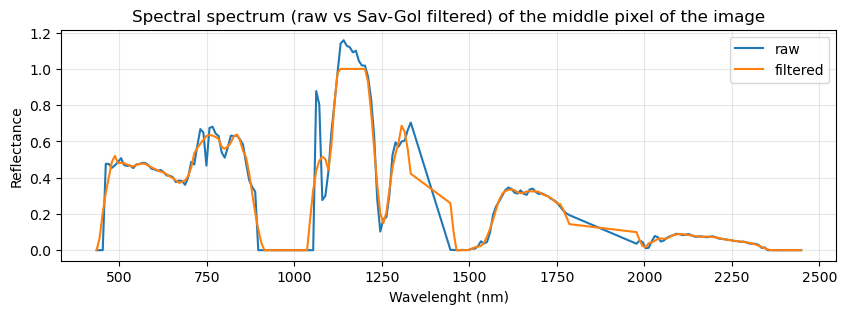

In [15]:
# Plot the reflectance spectrum before and after filtering
plt.figure(figsize=(10,3))
plt.plot(wvl, refl[rows//2, cols//2, :], label='raw')
plt.plot(wvl, filtered_cube[rows//2, cols//2, :], label='filtered')
plt.xlabel('Wavelenght (nm)')
plt.ylabel('Reflectance')
plt.title('Spectral spectrum (raw vs Sav-Gol filtered) of the middle pixel of the image')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Compute narrowband indices and features

# Define a function that returns the index of the nearest band in the wvl array to a targeted wavelanght
def band_nearest(wvl_array, target_nm):
    # Subtract each element of the wvl array for a specific number, and then take index of the minimum absolute result
    return np.argmin(np.abs(wvl_array - target_nm))

# Container of the calculated indices
indices = {}

# Narrowband Normalized Difference Vegetation Index
b750 = band_nearest(wvl, 750)
b670 = band_nearest(wvl, 670)
indices['NB_NDVI'] = (filtered_cube[:, :, b750] - filtered_cube[:, :, b670]) / (filtered_cube[:, :, b750] + filtered_cube[:, :, b670] + 1e-8)

# Narrowband Red-Edge Chlorophyll Index
b705 = band_nearest(wvl, 705)
indices['RECI'] = (filtered_cube[:, :, b750] - filtered_cube[:, :, b705]) / (filtered_cube[:, :, b750] + filtered_cube[:, :, b705] + 1e-8)

# SWIR Soil Proxy (2200, 2100 nm)
b2100 = band_nearest(wvl, 2100)
b2200 = band_nearest(wvl, 2200)
indices['SOIL_2100_2200'] = (filtered_cube[:, :, b2200] - filtered_cube[:, :, b2100]) / (filtered_cube[:, :, b2200] + filtered_cube[:, :, b2100] + 1e-8)

# Cellulose Absorption Index for dry vegetation
b2000 = band_nearest(wvl, 2000)
indices['CAI'] = 0.5 * (filtered_cube[:, :, b2000] + filtered_cube[:, :, b2200]) - filtered_cube[:, :, b2100]

# Stack indices
indices_stack = np.stack([indices[k] for k in sorted(indices.keys())], axis=2)

print(f'Indices: {sorted(indices.keys())}')

Indices: ['CAI', 'NB_NDVI', 'RECI', 'SOIL_2100_2200']


In [17]:
# Save denoised spectral bands to disk as float32 to avoid memory issues and delte it from RAM
np.save(r'C:\Users\Francesco\Python\earthlab\China\data\outputs\filtered_cube_float32.npy', filtered_cube.astype(np.float32))

# Delete from RAM heavy data that I won't use anymore
del filtered_cube
del filtered
del flat
# Clean Python's garbage collector from object no longer used
gc.collect()

4664

In [18]:
# Reload data as mmap (to avoid memory issues)
filtered_mmap = np.load(r'C:\Users\Francesco\Python\earthlab\China\data\outputs\filtered_cube_float32.npy', mmap_mode='r')

In [19]:
# Incremental Principal Component Analysis reduction with mmap (to avoid memory limitations)

# Set the batch size
BATCH_SIZE = 50000

# Set the IPCA
ipca = IncrementalPCA(n_components=PCA_COMPONENTS, batch_size=BATCH_SIZE)

# Reduce the filtered reflectance band cube into 2D
rows, cols, bands = filtered_mmap.shape
flat = filtered_mmap.reshape(-1, bands)

# Perform the IPCA on pixel groups
for i in range(0, flat.shape[0], BATCH_SIZE):
    batch = flat[i:i+BATCH_SIZE]
    ipca.partial_fit(batch)

# Transform the reflectance data
components = np.zeros((flat.shape[0], PCA_COMPONENTS), dtype=np.float32)
for i in range(0, flat.shape[0], BATCH_SIZE):
    components[i:i+BATCH_SIZE] = ipca.transform(flat[i:i+BATCH_SIZE])

# Convert the IPCA result to a 3D data
pca_cube = components.reshape(rows, cols, PCA_COMPONENTS)

In [20]:
# Linear spectral unmixing (endmemebers and fractions) with VCA (VectoriaL Component Analysis) and FCLS (Fully Constrained Least Squares) if pysptools_available, if not use a combination of Kmeans and NNLS (NoNegative linear Least Squares)

n_endmembers = 4 # bare soil, green vegetation, dry vegetation, shrub
if pysptools_available:
    # Reduce the filtered reflectance band cube into 2D
    flat_spec = filtered_mmap.reshape(-1, bands).T
    # Get the endmember matrix with VCA
    E = vca.VCA().run(flat, n_endmembers)
    E = E.T # transpose to have endmembers on rows
    # Estimate the fractions with FCLS
    F = fcls.FCLS()
    # Fractions (n_endmembers)
    fractions = F.run(flat_spec.T, E)
    fractions_cube = fractions.reshape(rows, cols, n_endmembers)
    # Name the endmembers
    fraction_names = ['bare_soil', 'green_vegetation', 'dry_vegetation', 'shrub']
    print('Endmembers estimated with VCA and fractions with FCLS:', fraction_names)
else:
    print('Pysptools not available. Using Kmeans centroids as pseudo-endmembers and NNLS unmixing')
    # Run KMeans clustering on spectral data to get pseudo-endmembers
    kmeans = KMeans(n_clusters=n_endmembers, random_state=42, n_init='auto').fit(flat)
    # Centroids as enmembers
    E = kmeans.cluster_centers_ # shape (n_endmembers, bands)
    # Allocate fractions array
    fractions = np.zeros((flat.shape[0], n_endmembers), dtype=np.float32)
    # Perform NNLS umxing for each pixel
    for i in range(flat.shape[0]):
        fractions[i], _ = nnls(E.T, flat[i])
    # Normalize fractions to sum to 1
    fractions_sum = fractions.sum(axis=1, keepdims=True)
    fractions_sum[fractions_sum == 0] = 1.0 # to avoid division by zero
    fractions = fractions / fractions_sum
    # Reshape to cube
    fractions_cube = fractions.reshape(rows, cols, n_endmembers)
    # Name the endmembers
    fraction_names = ['bare_soil', 'green_vegetation', 'dry_vegetation', 'shrub']
    print('Endmembers estimated with KMeans clustering for pseudo-endmembers and fractions with NNLS:', fraction_names)

Pysptools not available. Using Kmeans centroids as pseudo-endmembers and NNLS unmixing
Endmembers estimated with KMeans clustering for pseudo-endmembers and fractions with NNLS: ['bare_soil', 'green_vegetation', 'dry_vegetation', 'shrub']


In [25]:
# Classify the endmemebers based on their spectral characteristics
def classify_endmembers(E, wavelengths):
    
    n_end = E.shape[0]
    scores = []
    
    # Find band indices for key wavelengths
    def nearest_band(target):
        return np.argmin(np.abs(wvl - target))
    
    idx_red = nearest_band(670)
    idx_nir = nearest_band(850)
    idx_swir = nearest_band(1650) if np.max(wvl) > 1500 else None
    
    for i in range(n_end):
        em = E[i]
        red = em[idx_red]
        nir = em[idx_nir] 
        swir = em[idx_swir] if idx_swir is not None else np.mean(em[-5:])
        
        # Indicators
        greenness = nir / (red + 1e-6)
        dryness = swir / (nir + 1e-6)
        flatness = np.std(em) # low for soil
        
        scores.append({'index': i,
                   'greenness': greenness,
                   'dryness': dryness,
                   'flatness': flatness,
                   'red': red,
                   'nir': nir,
                   'swir': swir})
        
    # CLassification rules

    # Green vegetation: highest greenness
    gv = max(scores, key=lambda s: s['greenness'])
    
    # Dry vegetation: highest dryness
    dv = max([s for s in scores if s['index'] != gv['index']], key=lambda s: s['dryness'])
    
    # Soil: flattest spectrum (lowest std)
    soil = min([s for s in scores if s['index'] not in [gv['index'], dv['index']]], key=lambda s: s['flatness'])
    
    # Shrub: remaining spectrum
    shrub = [s for s in scores if s['index'] not in [gv['index'], dv['index'], soil['index']]][0]
    
    # Return ordered indices
    ordered = [soil['index'], gv['index'], dv['index'], shrub['index']]
    
    return ordered

# Apply ordering to enmembers and fraction cube
ordered_idx = classify_endmembers(E, wvl)

# Reorder endmember matrix
E_ordered = E[ordered_idx]

# Reorder fractions cube
fractions_cube_ordered = fractions_cube[:, :, ordered_idx]

print('Endmembers reordered/classified', fraction_names)

Endmembers reordered/classified ['bare_soil', 'green_vegetation', 'dry_vegetation', 'shrub']


In [26]:
# Save compact products for Google Earth Engine upload

# Function to write a GeoTIFF from a cube (array3d) with given metadata
def write_geotiff(array3d, outpath, base_meta):
    out_meta = base_meta.copy()
    out_meta.update({'count': array3d.shape[2],
                     'dtype': 'float32'})
    with rasterio.open(outpath, 'w', **out_meta) as dst:
        dst.write(np.transpose(array3d, (2, 0, 1)).astype('float32'))
    print('Wrote', outpath)

print('Exporting compact GeoTIFFs to', OUTPUT_DIR)
pca_out = os.path.join(OUTPUT_DIR, 'hyper_pca10.tif')
write_geotiff(pca_cube, pca_out, meta)
inds_out = os.path.join(OUTPUT_DIR, 'hyper_indices.tif')
write_geotiff(indices_stack, inds_out, meta)
fracs_out = os.path.join(OUTPUT_DIR, 'hyper_fractions.tif')
write_geotiff(fractions_cube_ordered, fracs_out, meta)

Exporting compact GeoTIFFs to C:\Users\Francesco\Python\earthlab\China\data\outputs
Wrote C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_pca10.tif
Wrote C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_indices.tif
Wrote C:\Users\Francesco\Python\earthlab\China\data\outputs\hyper_fractions.tif


In [23]:
# Google Earth Engine upload
try:
    ee.Initialize(project='ee-francescofustinoni')
    print('GEE initialized')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='ee-francescofustinoni')
    print('GEE authenticated and initialized')

GEE initialized


In [ ]:
# Load the hyperspectral assets in GEE
hyp_pca = ee.Image(HYP_PCA_ASSET)
hyp_ind = ee.Image(HYP_IND_ASSET)
hyp_frac = ee.Image(HYP_FRAC_ASSET)

# Build AOI from the Hyperspectral images
try:
    aoi = hyp_pca.geometry().bounds()
    print('AOI derived from uploaded Hyperion PCA asset geometry')
except Exception:
    # Build AOI from local image bbox by converting bbox corners into WGS84
    transformer_img = Transformer.from_crs(crs.to_string(), 'epsg:4326', always_xy=True)
    min_lon, min_lat = transformer_img.transform(minx, miny)
    max_lon, max_lat = transformer_img.transform(maxx, maxy)
    aoi = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
    print('AOI built from local image bbox')

AOI derived from uploaded Hyperion PCA asset geometry


In [ ]:
# Add Landsat8 (Sentinel-2 not available in the year 2014)
l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(aoi)
      .filterDate('2014-06-26', '2014-08-26') # Since the Hyperspectral image is on 2014-07-26, we select a 2 months range oround this date
      .filter(ee.Filter.lt('CLOUD_COVER', 20))
      .map(lambda img: img.multiply(0.0000275).add(-0.2)) # convert SR to reflectance 
      .median())

# Landsat8 NDVI
L8_NDVI = l8.normalizedDifference(['SR_B5', 'SR_B4']).rename('L8_NDVI')

In [29]:
# Add Sentinel-1
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(aoi)
      .filterDate('2014-06-26', '2014-08-26')
      .filter(ee.Filter.eq('instrumentMode', 'IW')) # Use the imaging mode Interferometric Wide
      .select(['vv', 'VH']) # Select the polarization
      .median())

In [30]:
# Add the DEM and the slope
dem = ee.Image('COPERNICUS/DEM/GLO30').clip(aoi)
slope = ee.Terrain.slope(dem)

In [31]:
# Build the predictor stack with fractional cover bands, L8_NDVI, S1 VV and VH, DEM, and slope
predictor_stack = (hyp_pca
                   .addBands(hyp_ind)
                   .addBands(hyp_frac.rename(['bare_frac', 'green_frac', 'dry_frac', 'shrub_frac']))
                   .addBands([L8_NDVI, s1.select('VV'), s1.select('VH'), dem, slope]))

print('Predictor stack prepared in GEE (including Hyp PCA, Hyp Indices, Hyp fractional cover bands, L8_NDVI, S1 VV, S1 VH, DEM, slope)')

Predictor stack prepared in GEE (including Hyp PCA, Hyp Indices, Hyp fractional cover bands, L8_NDVI, S1 VV, S1 VH, DEM, slope)
